In [1]:
"""
Author: Peratham Wiriyathammabhum


"""
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# import scipy.sparse.linalg as linalg
from numpy import linalg as LA
from scipy import linalg as SLA

# Import the libraries
# from sklearn.cross_decomposition import CCA

In [97]:
np.random.seed(0)

# Generate X and Y 100 instances with 10 dimensions each
X = np.random.randn(100, 10)
Y = X + np.random.randn(100, 10)	

In [98]:
ni, nd = X.shape

# centering
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
Y = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)

In [4]:
# cross correlation
B = np.dot(X.T, Y)

In [5]:
B.shape

(10, 10)

In [14]:
# eigen decomposition
u, s, v = LA.svd(B)
ind = np.argsort(s, axis=0) # sorting descending
v = v[ind]
u = u[:, ind]

# create coordinate matrix
proj_v = v[:,0:2] # projection matrix
proj_u = u[:,0:2] # projection matrix
X_r = np.matmul(X, proj_u)
Y_r = np.matmul(Y, proj_v)

In [15]:
X_r.shape

(100, 2)

In [16]:
Y_r.shape

(100, 2)

In [17]:
u.shape

(10, 10)

In [18]:
s

array([115.11593003, 101.15589965,  87.30288501,  82.49878237,
        74.19844905,  65.3630387 ,  56.73909993,  51.09943204,
        44.61321414,  35.71490705])

In [19]:
ind = np.argsort(s, axis=0) # sorting descending


In [20]:
ind

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [21]:
ind

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

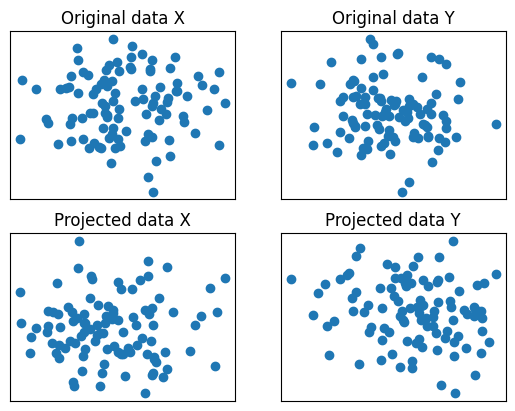

In [33]:
# plot
fig = plt.figure()

ax = fig.add_subplot(221)
ax.scatter(X[:, 0], X[:, 1])
ax.set_title("Original data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(222)
ax.scatter(Y[:, 0], Y[:, 1])
ax.set_title("Original data Y")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(223)
ax.scatter(X_r[:, 0], X_r[:, 1])
ax.set_title("Projected data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(224)
ax.scatter(Y_r[:, 0], Y_r[:, 1])
ax.set_title("Projected data Y")
plt.xticks([]), plt.yticks([])

# plt.axis('tight')
# plt.title('Projected data')
plt.show()

In [5]:
# cross correlation
Cxy = np.dot(X.T, Y)
Cxx = np.dot(X.T, X)
Cyx = np.dot(Y.T, X)
Cyy = np.dot(Y.T, Y)

In [36]:
Cxy.shape

(10, 10)

In [46]:
# eigen decomposition
A = np.dot(LA.pinv(Cyy, hermitian=True), Cyx)
A = np.dot(Cxy, A)
B = Cxx
sx, ux = SLA.eig(A, b=B)

In [47]:
A = np.dot(LA.pinv(Cxx, hermitian=True), Cxy)
A = np.dot(Cyx, A)
B = Cyy
sy, uy = SLA.eig(A, b=B)

In [50]:
ind = np.argsort(sx, axis=0) # sorting descending
ux = ux[:, ind]
ind = np.argsort(sy, axis=0) # sorting descending
uy = uy[:, ind]

In [52]:
# create coordinate matrix
proj_ux = ux[:,0:2] # projection matrix
proj_uy = uy[:,0:2] # projection matrix
X_r = np.matmul(X, proj_ux)
Y_r = np.matmul(Y, proj_uy)

In [53]:
ind

array([0, 9, 6, 8, 7, 5, 4, 3, 2, 1])

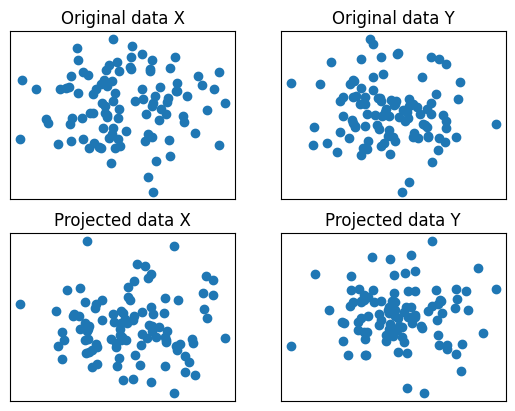

In [54]:
# plot
fig = plt.figure()

ax = fig.add_subplot(221)
ax.scatter(X[:, 0], X[:, 1])
ax.set_title("Original data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(222)
ax.scatter(Y[:, 0], Y[:, 1])
ax.set_title("Original data Y")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(223)
ax.scatter(X_r[:, 0], X_r[:, 1])
ax.set_title("Projected data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(224)
ax.scatter(Y_r[:, 0], Y_r[:, 1])
ax.set_title("Projected data Y")
plt.xticks([]), plt.yticks([])

# plt.axis('tight')
# plt.title('Projected data')
plt.show()

In [57]:
LA.norm(ux, ord=2, axis=0,)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [58]:
LA.norm(u, ord=2, axis=0,)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [60]:
# correlation scores
score = X_r.T @ Y_r

In [69]:
np.sum(np.abs(score[:]))/len(score[:].flatten())

np.float64(20.76411815929046)

In [70]:
score

array([[ 3.69589889e+01, -1.14284005e-13],
       [-9.16142300e-14, -4.60974838e+01]])

In [80]:
# correlation scores
score = X_r.T @ Y_r
corr_score = np.sum(np.abs(score[:]))/len(score[:].flatten())
print("Correlation score: {:0.4f}".format(corr_score))

Correlation score: 20.7641


In [121]:
# cross correlation
Cxy = np.dot(X.T, Y)
Cxx = X.T @ X
Cyx = np.dot(Y.T, X)
Cyy = Y.T @ Y

In [173]:
def _sq_inverse(X):
    # U, S, V = LA.svd(X, hermitian=True)
    X = X.copy()
    X = 0.5 * (X + X.conj().T)
    L, V = np.linalg.eigh(X)
    
    L = np.diag(1.0/np.sqrt(L))
    
    Xres = V.conj() @ L @ V.T.conj()
    return Xres

In [174]:
# sqrt inverse
Cxx_sqinv = _sq_inverse(Cxx)
Cyy_sqinv = _sq_inverse(Cyy)
B = Cxx_sqinv @ Cxy @ Cyy_sqinv

In [175]:
# eigen decomposition
u, s, v = LA.svd(B)
ind = np.argsort(s, axis=0) # sorting descending
v = v[ind]
u = u[:, ind]

In [176]:
# create coordinate matrix
proj_v = v[:,0:2] # projection matrix
proj_u = u[:,0:2] # projection matrix
X_r = np.matmul(X, proj_u)
Y_r = np.matmul(Y, proj_v)

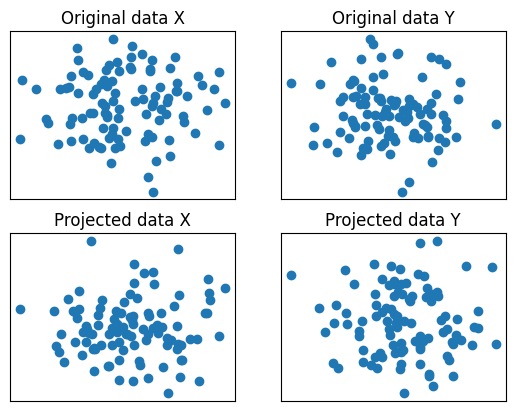

In [177]:
# plot
fig = plt.figure()

ax = fig.add_subplot(221)
ax.scatter(X[:, 0], X[:, 1])
ax.set_title("Original data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(222)
ax.scatter(Y[:, 0], Y[:, 1])
ax.set_title("Original data Y")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(223)
ax.scatter(X_r[:, 0], X_r[:, 1])
ax.set_title("Projected data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(224)
ax.scatter(Y_r[:, 0], Y_r[:, 1])
ax.set_title("Projected data Y")
plt.xticks([]), plt.yticks([])

# plt.axis('tight')
# plt.title('Projected data')
plt.show()

In [178]:
Cxx

array([[100.        ,   2.35146511,  -2.00994678,   0.45828648,
         -7.90116813,  -6.55487302,   9.33881051,   8.08784253,
        -12.4688009 ,   5.94226907],
       [  2.35146511, 100.        ,  -5.02454823,  -5.70451669,
         18.86660799,   2.78575917,  11.45522174,  -1.45500438,
         16.61949376,   7.83920839],
       [ -2.00994678,  -5.02454823, 100.        ,   8.64956526,
          0.21955997,  13.09196395,  -5.05368585,  -1.17981617,
         -4.89116025,   8.03426959],
       [  0.45828648,  -5.70451669,   8.64956526, 100.        ,
          6.7134622 ,   7.23464178,  11.79946937, -11.8156681 ,
          5.28184164, -16.19258911],
       [ -7.90116813,  18.86660799,   0.21955997,   6.7134622 ,
        100.        , -13.17917187,  10.40435738,  -8.28574983,
         -3.71076764,  -5.65219658],
       [ -6.55487302,   2.78575917,  13.09196395,   7.23464178,
        -13.17917187, 100.        , -15.77156661,  -5.21448592,
          9.93968045,   6.20352968],
       [  

In [179]:
Cxx_sqinv

array([[ 1.01891979e-01, -2.30945040e-03,  9.79295372e-04,
        -1.31826895e-03,  5.02617984e-03,  2.77922314e-03,
        -5.23198077e-03, -3.54174213e-03,  6.98321482e-03,
        -3.12471621e-03],
       [-2.30945040e-03,  1.03700866e-01,  2.41499912e-03,
         3.89552929e-03, -1.07061379e-02, -2.89003227e-03,
        -5.14545951e-03, -3.64598878e-05, -8.80017502e-03,
        -4.06395705e-03],
       [ 9.79295372e-04,  2.41499912e-03,  1.01499681e-01,
        -4.75205812e-03, -1.01989765e-03, -6.35406784e-03,
         1.75756611e-03,  2.31946337e-04,  2.86344593e-03,
        -4.63369636e-03],
       [-1.31826895e-03,  3.89552929e-03, -4.75205812e-03,
         1.03079816e-01, -3.54240500e-03, -4.59327739e-03,
        -6.33784343e-03,  5.19983697e-03, -2.65379499e-03,
         8.37707527e-03],
       [ 5.02617984e-03, -1.07061379e-02, -1.01989765e-03,
        -3.54240500e-03,  1.03493387e-01,  7.05082255e-03,
        -3.91800327e-03,  3.92120680e-03,  3.85719984e-03,
         2.

In [180]:
Cxx_sqinv @  Cxx @ Cxx_sqinv

array([[ 1.00000000e+00, -1.52805201e-16,  2.70779724e-17,
        -1.33460067e-16, -9.47536277e-16, -2.61522599e-16,
        -9.27526026e-16,  2.19786263e-16, -2.70042477e-16,
         1.25139986e-16],
       [-1.70304871e-16,  1.00000000e+00, -9.86856428e-16,
         2.02282364e-16,  1.06037995e-15, -4.55051191e-16,
        -4.36165506e-16, -4.48501794e-16,  1.11363178e-15,
        -4.34709351e-16],
       [ 1.16661942e-16, -1.00288804e-15,  1.00000000e+00,
         7.09809306e-16, -2.49532646e-16, -2.52776400e-16,
        -1.04964257e-15, -3.62081931e-17,  1.07265733e-15,
         6.55548998e-17],
       [-1.94202524e-16,  1.91894761e-16,  7.40300058e-16,
         1.00000000e+00,  1.10130970e-15,  1.28050831e-16,
         6.62311302e-17, -1.31400692e-17,  6.72776931e-16,
        -6.84482929e-16],
       [-9.94530045e-16,  1.10228249e-15, -1.80878335e-16,
         1.06243195e-15,  1.00000000e+00, -7.17143889e-16,
         1.59690964e-15, -1.57820655e-16, -2.33796568e-17,
        -4.

In [183]:
result = Cxx_sqinv @  Cxx @ Cxx_sqinv 
np.allclose(result, np.eye(len(Cxx)), atol=1e-12)

True

In [184]:
U,S,V = LA.svd(Cxx, hermitian=True)

In [185]:
U==V.T

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [186]:
SLA.ishermitian(Cxx)

True

In [187]:
SLA.ishermitian(Cxx_sqinv, atol=1e-13)

True

In [188]:
Cxx_sqinv

array([[ 1.01891979e-01, -2.30945040e-03,  9.79295372e-04,
        -1.31826895e-03,  5.02617984e-03,  2.77922314e-03,
        -5.23198077e-03, -3.54174213e-03,  6.98321482e-03,
        -3.12471621e-03],
       [-2.30945040e-03,  1.03700866e-01,  2.41499912e-03,
         3.89552929e-03, -1.07061379e-02, -2.89003227e-03,
        -5.14545951e-03, -3.64598878e-05, -8.80017502e-03,
        -4.06395705e-03],
       [ 9.79295372e-04,  2.41499912e-03,  1.01499681e-01,
        -4.75205812e-03, -1.01989765e-03, -6.35406784e-03,
         1.75756611e-03,  2.31946337e-04,  2.86344593e-03,
        -4.63369636e-03],
       [-1.31826895e-03,  3.89552929e-03, -4.75205812e-03,
         1.03079816e-01, -3.54240500e-03, -4.59327739e-03,
        -6.33784343e-03,  5.19983697e-03, -2.65379499e-03,
         8.37707527e-03],
       [ 5.02617984e-03, -1.07061379e-02, -1.01989765e-03,
        -3.54240500e-03,  1.03493387e-01,  7.05082255e-03,
        -3.91800327e-03,  3.92120680e-03,  3.85719984e-03,
         2.